In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"data\sf_NGC7538_SNR3.csv")

print(df.head())
print(df.columns.tolist())
print("N rows:", len(df))
print("Finite Dphi:", np.isfinite(df["Dphi"]).sum())
print("Positive Npairs:", (df["Npairs"] > 0).sum())
print(df[["R_pix", "Dphi", "Npairs"]].tail())

  object_name       mask_name  R_pix      Dphi  Npairs
0     NGC7538  SNR>3_QUALITY0    1.0  0.103812    5480
1     NGC7538  SNR>3_QUALITY0    2.0  0.126539    7856
2     NGC7538  SNR>3_QUALITY0    3.0  0.159988    9994
3     NGC7538  SNR>3_QUALITY0    4.0  0.203399   19142
4     NGC7538  SNR>3_QUALITY0    5.0  0.242016   15876
['object_name', 'mask_name', 'R_pix', 'Dphi', 'Npairs']
N rows: 138
Finite Dphi: 138
Positive Npairs: 138
     R_pix      Dphi  Npairs
133  134.0  0.500939    1834
134  135.0  0.502797    1692
135  136.0  0.494242    1658
136  137.0  0.498300    1456
137  138.0  0.513090    1366


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def plot_all_fireplace_sf(
    base_dir="report/fireplace_results/plots",
    pattern="*_sf_B_strict_snr3.csv",
    x_col="R_pix",          # можно заменить на "R_pc"
    y_col="Dphi",
    figsize=(11, 8),
    alpha=0.8,
    lw=1.8,
    savepath=None,
):
    base_dir = Path(base_dir)
    csv_files = sorted(base_dir.rglob(pattern))

    if not csv_files:
        print(f"No files found in {base_dir} with pattern {pattern}")
        return

    plt.figure(figsize=figsize)

    plotted = 0
    skipped = []

    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)

            if x_col not in df.columns or y_col not in df.columns:
                skipped.append((csv_file.name, list(df.columns)))
                continue

            # подпись: объект + маска
            object_name = df["object_name"].iloc[0] if "object_name" in df.columns else csv_file.parent.name
            mask_name = df["mask_name"].iloc[0] if "mask_name" in df.columns else csv_file.stem
            label = f"{object_name} | {mask_name}"

            plt.plot(
                df[x_col].values,
                df[y_col].values,
                lw=lw,
                alpha=alpha,
                label=label
            )
            plotted += 1

        except Exception as e:
            skipped.append((csv_file.name, str(e)))

    if plotted == 0:
        print("Files were found, but none could be plotted.")
        print("Skipped:")
        for s in skipped:
            print(s)
        return

    angle_deg = 53
    level_53 = np.sin(np.deg2rad(angle_deg))**2
    
    plt.axhline(0.5, color='gray', linestyle='--', label='Random limit (Lazarian): Dφ = 0.5')
    plt.axhline(level_53, color='orange', linestyle=':', label=f'Equivalent to Δφ = {angle_deg}°: Dφ ≈ {level_53:.2f}')

    plt.xlabel(x_col)
    plt.ylabel("Dphi")
    plt.title("All FIREPLACE Structure Functions")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7, ncol=2, frameon=False)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Saved to: {savepath}")

    plt.show()

    if skipped:
        print("\nSkipped files:")
        for s in skipped:
            print(s)

    print(f"\nPlotted {plotted} files.")



    

Saved to: all_fireplace_sf_logx.png


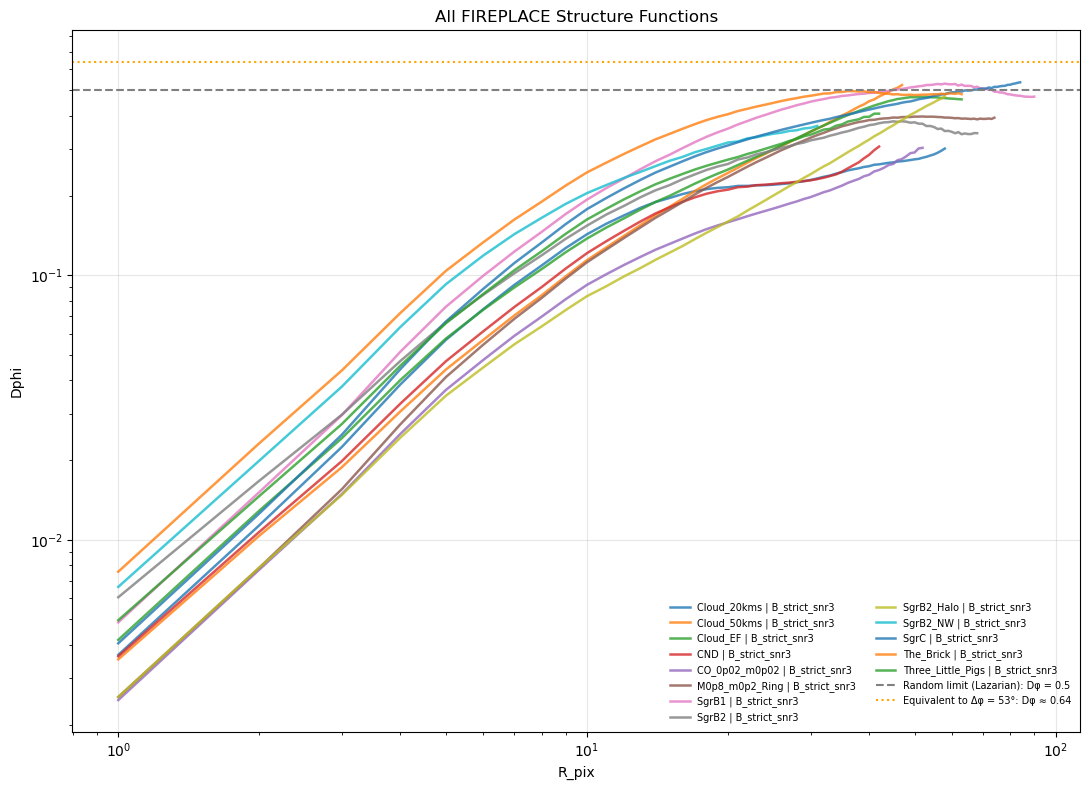


Plotted 13 files.


In [16]:
plot_all_fireplace_sf(
    base_dir="report/fireplace_results/plots",
    savepath="all_fireplace_sf_logx.png"
)


=== SF ANALYSIS RESULT ===
object_name: NGC7538
mask_name: SNR>3_QUALITY0
dataset: None
n_points_raw: 138
n_points_valid: 138
r_max_pix: 138.0
plateau_detected: detected
plateau_level: 0.487189875268258
plateau_scatter: 0.015742917540901537
saturation_scale_pix: 36.0
saturation_scale_pc: None
tail_start_pix: 104.0
notes: 

=== BREAK ESTIMATION ===
r_break_pix: 19.0
r_break_pc: None
break_idx: 18
slope_left: 0.5500205579850755
slope_right: -0.035012168838557456
intercept_left: -0.978735380893258
intercept_right: -0.23679600977805265
sse_total: 0.031820312572356894
status: ok

=== MACH ESTIMATION ===
object_name: NGC7538
mask_name: SNR>3_QUALITY0
lA_proxy_pix: 19.0
L_proxy_pix: 212.13203435596427
MA_proxy: 2.2350344349200966
status: ok
notes: Proxy estimate using lA ~ r_break and L ~ skeleton spine length

Saved summary to: data\sf_NGC7538_SNR3_analysis_summary.csv
Saved break summary to: data\sf_NGC7538_SNR3_break_summary.csv
Saved Mach summary to: data\sf_NGC7538_SNR3_mach_summary.csv

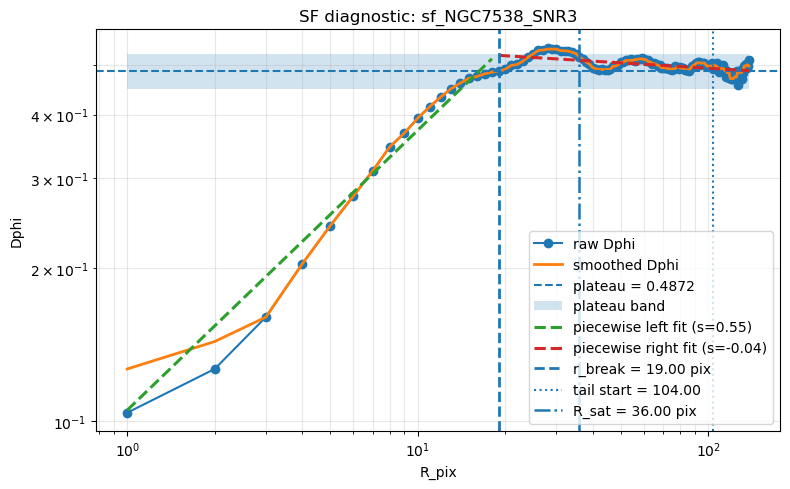

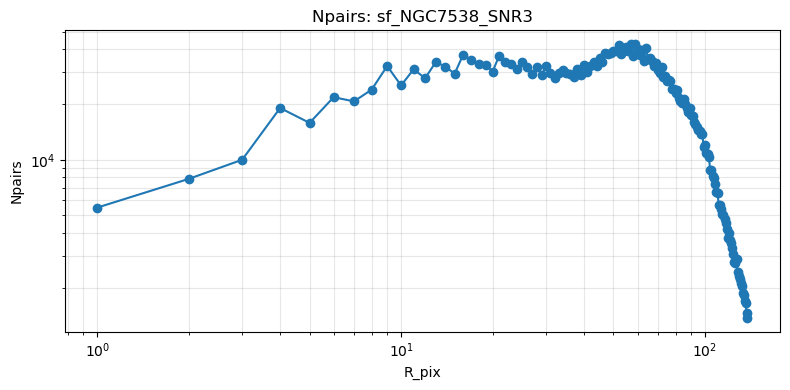

In [17]:
from SF_analysis import *

# =========================
# Run on one file
# =========================
if __name__ == "__main__":
    sf_path = r"data\sf_NGC7538_SNR3.csv"

    config = SFAnalysisConfig(
        r_col="R_pix",
        dphi_col="Dphi",
        npairs_col="Npairs",
        r_pc_col="R_pc",
        min_points=8,
        min_npairs=30,
        tail_fraction=0.25,
        smooth_window=5,
        rel_tol=0.08,
        sigma_tol=2.0,
        require_consecutive_tail_points=3,
    )

    df = load_sf_csv(sf_path)
    result, valid, extras = analyze_sf_table(df, config, Path('data/'))

    print("\n=== SF ANALYSIS RESULT ===")
    for key, value in result.__dict__.items():
        print(f"{key}: {value}")

    break_info = extras.get("break_info", {})
    print("\n=== BREAK ESTIMATION ===")
    for key, value in break_info.items():
        print(f"{key}: {value}")

    break_info = extras.get("break_info", {})
    r_break_pix = break_info.get("r_break_pix", None)

    L_spine_pix = 150*np.sqrt(2)

    mach_result = estimate_mach_from_break_and_length(
        r_break_pix=r_break_pix,
        # r_break_pix=result.saturation_scale_pix,
        L_pix=L_spine_pix,
        object_name=result.object_name,
        mask_name=result.mask_name,
    )

    print("\n=== MACH ESTIMATION ===")
    for key, value in mach_result.__dict__.items():
        print(f"{key}: {value}")

    if len(valid) > 0:
        out_dir = Path(sf_path).parent

        # summary of plateau/saturation
        out_summary = pd.DataFrame([result.__dict__])
        out_csv = out_dir / (Path(sf_path).stem + "_analysis_summary.csv")
        out_summary.to_csv(out_csv, index=False)

        # summary of break
        out_break = pd.DataFrame([break_info])
        out_break_csv = out_dir / (Path(sf_path).stem + "_break_summary.csv")
        out_break.to_csv(out_break_csv, index=False)

        out_mach = pd.DataFrame([mach_result.__dict__])
        out_mach_csv = out_dir / (Path(sf_path).stem + "_mach_summary.csv")
        out_mach.to_csv(out_mach_csv, index=False)

        print(f"\nSaved summary to: {out_csv}")
        print(f"Saved break summary to: {out_break_csv}")
        print(f"Saved Mach summary to: {out_mach_csv}")

        plot_sf_diagnostic(
            valid,
            result,
            extras,
            config,


            
            title=f"SF diagnostic: {Path(sf_path).stem}",
        )
        plot_npairs(valid, config, title=f"Npairs: {Path(sf_path).stem}")
    else:
        print("\nNo valid points after filtering.")